# Capstone Project

## 1. Overview
### Question: What Effect does Social Media, such as Usage and Choice of Platform, Have on a User’s Emotional Wellbeing? 


### 1.1 Business Context
It is important to be able to identify social media users who may require intervention for their emotional wellbeing. If the question is left unanswered, social media users who are emotionally unwell may suffer in silence without anyone ever noticing it. With a predictive model capable of identifying potentially emotionally unwell social media users, emotional and mental wellness companies and institutions can target their ads at the potentially emotionally unwell users predicted by the model. 

The notebook aims to find a supervised classification machine learning model that can predict users based on their social media use into different dominant emotion groups, such as Happiness, Sadness, Anger, Anxiety, Boredom, and Neutral, and identify the top 3 drivers impacting a social media user's emotional wellbeing. 

### 1.2 Techniques for Analysis
-	Run EDA to examine data distribution.
-	Preprocess data to handle missing values, encode categorical columns, scale numerical columns, and label-encode the categorical outcomes. The data source provides 3 files, a training set, a validation set, and a test set, all of which need to be preprocessed.
-	Supervised machine learning: Run logistic regression, decision tree classifier, and SVM using grid search CV with respected hyperparameters. Calculate the scores against the validation set and find the best model.

### 1.3 Success Criteria
A predictive classification model of more than 70% accuracy (>10% improvement over baseline model) predicting a social media user's dominant emotion, while identifying the top three drivers impacting thedominant emotion. 


## 2. Data Collection and Sourcing

Since it's completely empty, drop the column.

### 2.1 Data Sourcing

The data is sourced from the Kaggle [website](https://www.kaggle.com/datasets/emirhanai/social-media-usage-and-emotional-well-being?resource=download), titled "Social Media Usage and Emotional Well-Being". The dataset has 10 columns and total of 1400 rows, which is adequate for data analysis. It can be used for educational and research purposes in accordance with the MIT license.

The followings are the descrptions for the 10 features from the data source website: 

```
User_ID: Unique identifier for each user.
Age: Age of the user in years.
Gender: Gender identity of the user (Female, Male, Non-binary).
Platform: The social media platform used by the user (e.g., Instagram, Twitter, Facebook, LinkedIn, Snapchat, Whatsapp, Telegram).
Daily_Usage_Time (minutes): Total minutes spent daily on the specified platform.
Posts_Per_Day: Number of posts made per day.
Likes_Received_Per_Day: Number of likes received per day.
Comments_Received_Per_Day: Number of comments received per day.
Messages_Sent_Per_Day: Number of messages sent per day.
Dominant_Emotion: The dominant emotional state of the user during the day (e.g., Happiness, Sadness, Anger, Anxiety, Boredom, Neutral).
```


The val.csv file has a ParserError in line 91 with 11 fields instead of 10, which needs to be manually fixed before the file could be read in.

In [28]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline, make_pipeline

from sklearn.svm import SVC
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.svm import SVC

import time
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import ConfusionMatrixDisplay, classification_report, RocCurveDisplay
from sklearn.inspection import permutation_importance
from sklearn import set_config
# Set color scheme
colors = sns.color_palette('Pastel1')
sns.set_palette('Pastel1')

# Supress warnings
import os
os.environ["PYDEVD_DISABLE_FILE_VALIDATION"] = "1"
pd.options.mode.chained_assignment = None # Disable the warning
warnings.simplefilter(action='ignore', category=FutureWarning)
set_config("display")
plt.rcParams.update({'font.size': 12})
RANDOM_STATE = 42

### 2.2 Read in the Data

I am Combining the 3 datasets into 1 file, so that I can split the train set and test set on my own with all the data combined. There is a major formatting error in the val.csv file, which requires a simple manual fix in Excel in order for the file to load. The file has been edited and saved.

In [29]:
# Read in 3 separate files and concatenate them into one dataframe
df1 = pd.read_csv('data/test.csv')
df2 = pd.read_csv('data/train.csv')
df3 = pd.read_csv('data/val.csv')
social = pd.concat([df1,df2, df3], ignore_index=True)

## 3. Exploratory Data Analysis and Data Cleaning

### 3.1 Data Cleaning

Drop `User_ID` column because it is not useful.

In [30]:
# Drop 'User_ID' column
social.drop(columns=['User_ID'], inplace=True)

In [31]:
social.tail()

,Age,Gender,Platform,Daily_Usage_Time (minutes),Posts_Per_Day,Likes_Received_Per_Day,Comments_Received_Per_Day,Messages_Sent_Per_Day,Dominant_Emotion,Unnamed: 10
1395,29,Female,LinkedIn,55,2.0,15.0,5.0,10,Neutral,NaN
1396,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1397,21,Female,Facebook,75,2.0,25.0,13.0,19,Anxiety,NaN
1398,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1399,24,Female,Instagram,200,6.0,100.0,18.0,39,Neutral,NaN


There are rows where all the values are empty. Find all the empty rows and drop them.

In [32]:
# Find indices of empty-valued rows
empty_rows_mask = social.isna().all(axis=1)
empty_row_indices = social.index[empty_rows_mask].tolist()
social.drop(empty_row_indices, inplace=True)
social.reset_index(drop=True, inplace=True)
social.head()

,Age,Gender,Platform,Daily_Usage_Time (minutes),Posts_Per_Day,Likes_Received_Per_Day,Comments_Received_Per_Day,Messages_Sent_Per_Day,Dominant_Emotion,Unnamed: 10
0,27,Female,Snapchat,120,4.0,40.0,18.0,22,Neutral,NaN
1,21,Non-binary,Snapchat,60,1.0,18.0,7.0,12,Neutral,NaN
2,28,Non-binary,Snapchat,115,3.0,38.0,18.0,27,Anxiety,NaN
3,27,Male,Telegram,105,3.0,48.0,20.0,28,Anxiety,NaN
4,21,Non-binary,Facebook,55,3.0,17.0,7.0,12,Neutral,NaN


Check the last `Unnamed: 10` column.

In [33]:
# Check the last "Unnamed: 10" column
social['Unnamed: 10'].value_counts()

Unnamed: 10
Happiness    1
Anger        1
Name: count, dtype: int64

This looks like a formatting error. Check these two rows.

In [34]:
# Find the indices and examine
indices_a = social.index[social['Unnamed: 10'] == 'Anger']
indices_h = social.index[social['Unnamed: 10'] == 'Happiness']
indices= list(indices_a) + list(indices_h)
social.iloc[indices]

,Age,Gender,Platform,Daily_Usage_Time (minutes),Posts_Per_Day,Likes_Received_Per_Day,Comments_Received_Per_Day,Messages_Sent_Per_Day,Dominant_Emotion,Unnamed: 10
1203,30,Female,Facebook,90,4.0,38.0,20.0,24,NaN,Anger
1182,Female,30,Female,Instagram,210.0,5.0,87.0,30,32,Happiness


The data are not entered into the correct columns. Fix the errors. 

In [35]:
# For the first row, move 'Anger' to the target column
social.loc[indices_a, 'Dominant_Emotion'] = social.loc[indices_a, 'Unnamed: 10'] 
social.loc[indices_a, 'Unnamed: 10'] = None
# For the second row, shift all the values to the left
social.iloc[indices_h]= social.iloc[indices_h].shift(-1, axis=1)
social.iloc[indices]

,Age,Gender,Platform,Daily_Usage_Time (minutes),Posts_Per_Day,Likes_Received_Per_Day,Comments_Received_Per_Day,Messages_Sent_Per_Day,Dominant_Emotion,Unnamed: 10
1203,30,Female,Facebook,90,4.0,38.0,20.0,24,Anger,None
1182,30,Female,Instagram,210.0,5.0,87.0,30,32,Happiness,None


Drop `Unnamed: 10` column because it is empty.

In [36]:
# Drop the column
social.drop(columns=['Unnamed: 10'], inplace=True)

In [37]:
social.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1252 entries, 0 to 1251
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Age                         1252 non-null   object 
 1   Gender                      1251 non-null   object 
 2   Platform                    1251 non-null   object 
 3   Daily_Usage_Time (minutes)  1251 non-null   object 
 4   Posts_Per_Day               1251 non-null   float64
 5   Likes_Received_Per_Day      1251 non-null   float64
 6   Comments_Received_Per_Day   1251 non-null   object 
 7   Messages_Sent_Per_Day       1251 non-null   object 
 8   Dominant_Emotion            1250 non-null   object 
dtypes: float64(2), object(7)
memory usage: 88.2+ KB


It is odd many supposedly numerical columns have datatype as `object`. Check the columns one by one.

In [38]:
social['Age'].value_counts()

Age
28                                                      120
27                                                      116
29                                                      111
26                                                       88
22                                                       86
24                                                       84
31                                                       82
25                                                       79
21                                                       69
23                                                       68
33                                                       67
30                                                       54
32                                                       47
35                                                       46
34                                                       44
Female                                                   34
Male                                

The last four values are not `Age`. Check and fix the errors. First, drop the row that is obviously an error.

In [39]:
# Drop the row
index_error=social.index[social['Age'] == ' işte mevcut veri kümesini 1000 satıra tamamlıyorum:'].tolist()
social.drop(index_error, inplace=True)
social.reset_index(drop=True, inplace=True)

In [40]:
social.tail()

,Age,Gender,Platform,Daily_Usage_Time (minutes),Posts_Per_Day,Likes_Received_Per_Day,Comments_Received_Per_Day,Messages_Sent_Per_Day,Dominant_Emotion
1246,27,Non-binary,LinkedIn,55,1.0,9.0,2.0,11,Anxiety
1247,26,Non-binary,Facebook,45,1.0,8.0,4.0,12,Sadness
1248,29,Female,LinkedIn,55,2.0,15.0,5.0,10,Neutral
1249,21,Female,Facebook,75,2.0,25.0,13.0,19,Anxiety
1250,24,Female,Instagram,200,6.0,100.0,18.0,39,Neutral


Examine the rows where the data seem to have been entered incorrectly for `Age`. 

In [41]:
# Find the indices for the wrong values and examine the rows
indices_f = social.index[social['Age'] == 'Female']
indices_m = social.index[social['Age'] == 'Male']
indices_n = social.index[social['Age'] == 'Non-binary']
indices_age = list(indices_f) + list(indices_m) + list(indices_n)
social.iloc[indices_age].sample(5)

,Age,Gender,Platform,Daily_Usage_Time (minutes),Posts_Per_Day,Likes_Received_Per_Day,Comments_Received_Per_Day,Messages_Sent_Per_Day,Dominant_Emotion
884,Non-binary,24,Snapchat,85.0,3.0,33.0,20.0,18.0,Happiness
1174,Female,22,LinkedIn,90,10.0,12.0,5.0,11,Neutral
1182,Female,24,Twitter,85,6.0,42.0,15.0,21,Boredom
1179,Female,26,Instagram,90,3.0,39.0,10.0,21,Neutral
389,Male,31,Telegram,85.0,3.0,45.0,20.0,28.0,Sadness


The `Gender` and `Age` columns are swapped in these rows. Fix.

In [42]:
# Create boolean mask for the error indices.
condition = social.index.isin(indices_age)
# Swap the values.
social.loc[condition, ['Age', 'Gender']] = social.loc[condition, ['Gender', 'Age']].values

Check if the `Age` column is fixed after swapping values with `Gender` for the erroneous rows.

In [43]:
social['Age'].value_counts()

Age
28          130
27          125
29          121
22           94
24           93
26           93
31           90
25           85
21           73
33           73
23           70
30           56
34           50
32           49
35           48
Facebook      1
Name: count, dtype: int64

Check the row where `Age` is `Facebook` to see if the data can be fixed.

In [44]:
social.query ("Age =='Facebook'")

,Age,Gender,Platform,Daily_Usage_Time (minutes),Posts_Per_Day,Likes_Received_Per_Day,Comments_Received_Per_Day,Messages_Sent_Per_Day,Dominant_Emotion
1196,Facebook,Non-binary,55,1,9.0,2.0,11.0,Anxiety,NaN


It is not obvious how to fix row number 1196. Drop the row.

In [45]:
# Drop row 1196
social.drop(1196, inplace=True)
social.reset_index(drop=True, inplace=True)

Check the rest of numerical columns to see if there are odd values.

In [46]:
col_list = social.columns.to_list()
for col in col_list:
    print(social[col].value_counts())

Age
28    130
27    125
29    121
22     94
24     93
26     93
31     90
25     85
21     73
33     73
23     70
30     56
34     50
32     49
35     48
Name: count, dtype: int64
Gender
Female        452
Male          444
Non-binary    353
Marie           1
Name: count, dtype: int64
Platform
Instagram    304
Facebook     249
Twitter      244
LinkedIn     154
Snapchat     112
Telegram      98
Whatsapp      89
Name: count, dtype: int64
Daily_Usage_Time (minutes)
70       91
75       91
60       90
90       85
85       65
         ..
30        1
210.0     1
180       1
125       1
155       1
Name: count, Length: 63, dtype: int64
Posts_Per_Day
2.0     286
1.0     243
3.0     215
4.0     198
6.0     136
5.0      87
7.0      47
8.0      37
10.0      1
Name: count, dtype: int64
Likes_Received_Per_Day
30.0     80
12.0     64
20.0     63
50.0     48
22.0     43
65.0     41
37.0     41
15.0     40
10.0     40
40.0     39
45.0     39
35.0     38
18.0     37
17.0     32
27.0     32
25.0     27
6

`Gender` column requires attention. The other columns appear okay. Check `Gender` column.

In [47]:
social['Gender'].value_counts()

Gender
Female        452
Male          444
Non-binary    353
Marie           1
Name: count, dtype: int64

Check the row with `Gender` == `Marie`.

In [49]:
# Check the row with "Gender" value == "Marie"
index_g = social.index[social['Gender'] == 'Marie']
social.iloc[index_g]

,Age,Gender,Platform,Daily_Usage_Time (minutes),Posts_Per_Day,Likes_Received_Per_Day,Comments_Received_Per_Day,Messages_Sent_Per_Day,Dominant_Emotion
79,32,Marie,Instagram,130,5.0,80.0,28.0,31,Neutral


This looks like an error. The gender for someone named "Marie" should be "Female". Fix it.

In [50]:
# Change "Marie" to "Female"
social['Gender'].iloc[index_g]='Female'

For the numberical features with datatype of `object`, conver to `int`. 

In [51]:
cols_to_convert = ['Age','Daily_Usage_Time (minutes)','Posts_Per_Day','Likes_Received_Per_Day','Comments_Received_Per_Day','Messages_Sent_Per_Day']
for col in cols_to_convert:
    social[col] = pd.to_numeric(social[col], downcast='integer') 

#### Remove Outliers

The earlier value count of `Dominant_Emotion` shows that there is an outlier.

In [52]:
social['Dominant_Emotion'].value_counts()

Dominant_Emotion
Neutral      258
Happiness    242
Anxiety      223
Sadness      199
Boredom      174
Anger        153
Agression      1
Name: count, dtype: int64

Regardless of the typo, `Aggression` is an outlier of only 0.08 percent of the data. Drop the row.

In [53]:
social.drop(social[social['Dominant_Emotion']=='Agression'].index, inplace=True)
social.reset_index(drop=True, inplace=True)
social.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1249 entries, 0 to 1248
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Age                         1249 non-null   int8  
 1   Gender                      1249 non-null   object
 2   Platform                    1249 non-null   object
 3   Daily_Usage_Time (minutes)  1249 non-null   int16 
 4   Posts_Per_Day               1249 non-null   int8  
 5   Likes_Received_Per_Day      1249 non-null   int8  
 6   Comments_Received_Per_Day   1249 non-null   int8  
 7   Messages_Sent_Per_Day       1249 non-null   int8  
 8   Dominant_Emotion            1249 non-null   object
dtypes: int16(1), int8(5), object(3)
memory usage: 37.9+ KB


Before applying IQR, first identify numerical and categorical features.

In [54]:
# Identify numerical and categorical column names
cat_features = social.select_dtypes(include=["object", "category"]).columns.tolist()
num_features = social.select_dtypes(include=[np.number]).columns.tolist()

# Remove target variable from categorical features list
cat_features.remove('Dominant_Emotion')  
print("Categorical columns:", cat_features)
print("Numerical columns:", num_features)

Categorical columns: ['Gender', 'Platform']
Numerical columns: ['Age', 'Daily_Usage_Time (minutes)', 'Posts_Per_Day', 'Likes_Received_Per_Day', 'Comments_Received_Per_Day', 'Messages_Sent_Per_Day']


Apply IQR to numerical features to remove outliers.

In [55]:
# Remove outliers for numerical columns using IQR method
previous_data_size = social.shape[0]
for col in num_features: 
    Q1 = social[col].quantile(0.25)
    Q3 = social[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    social = social[(social[col] >= lower_bound) & (social[col] <= upper_bound)]

# Check resulting data after outliers and unreasonable data rows are removed
social.info()
print(f"\nThis removes {(previous_data_size - social.shape[0])/previous_data_size*100:.2f}% of the data.")

<class 'pandas.core.frame.DataFrame'>
Index: 1199 entries, 0 to 1247
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Age                         1199 non-null   int8  
 1   Gender                      1199 non-null   object
 2   Platform                    1199 non-null   object
 3   Daily_Usage_Time (minutes)  1199 non-null   int16 
 4   Posts_Per_Day               1199 non-null   int8  
 5   Likes_Received_Per_Day      1199 non-null   int8  
 6   Comments_Received_Per_Day   1199 non-null   int8  
 7   Messages_Sent_Per_Day       1199 non-null   int8  
 8   Dominant_Emotion            1199 non-null   object
dtypes: int16(1), int8(5), object(3)
memory usage: 45.7+ KB

This removes 4.00% of the data.


The removal of 4 percent data is acceptable (< 5%).

### 3.2 Exploratory Data Analysis

#### Examine and Plot Target and Categorical Data Distributions

Check whether target column distribution is balanced or umbalanced.

In [56]:
# Set target column
target = 'Dominant_Emotion'
# Check target variable distribution
social[target].value_counts(normalize=True)

Dominant_Emotion
Neutral      0.213511
Anxiety      0.175146
Happiness    0.172644
Sadness      0.165972
Boredom      0.145121
Anger        0.127606
Name: proportion, dtype: float64

The outcome classes are balanced.

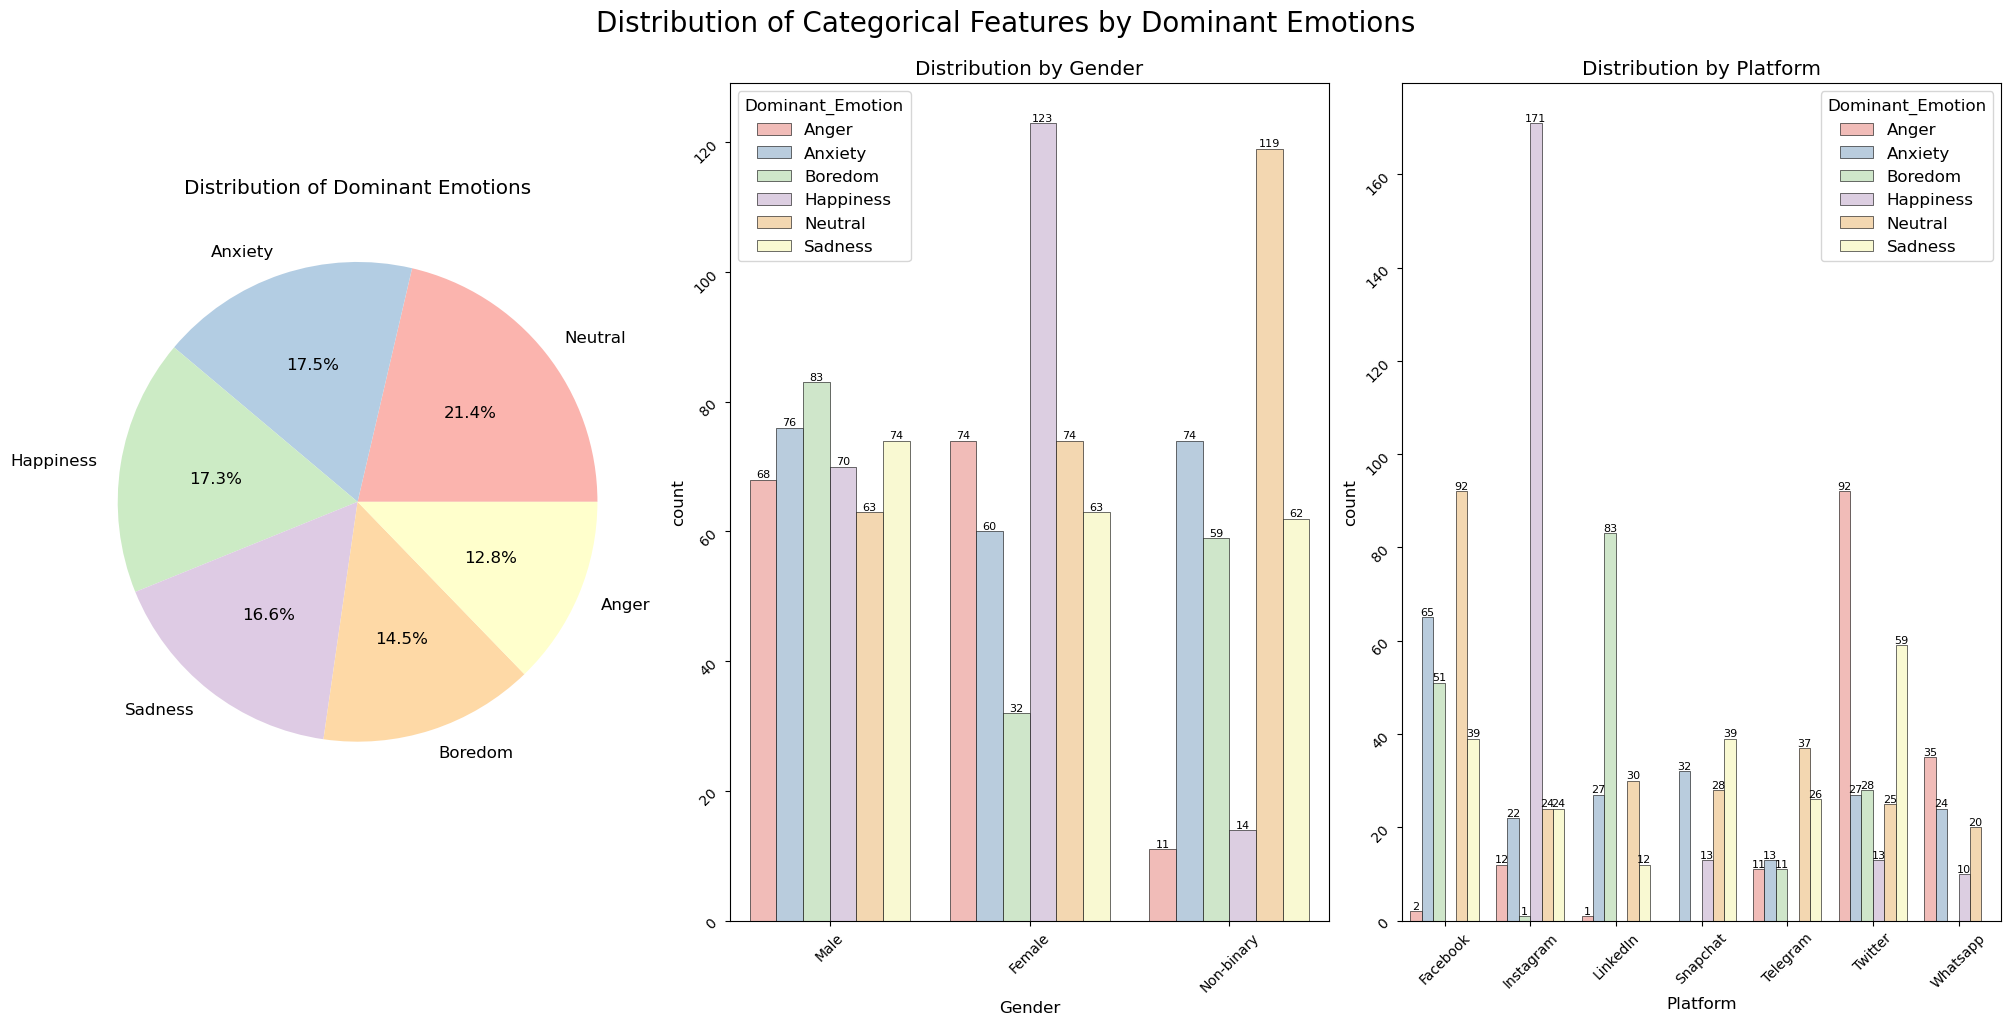

In [57]:
social[target] = pd.Categorical(social[target], categories=social[target].unique().tolist().sort())
# Set up subplots
fig,_axes = plt.subplots(nrows=1, ncols=3, figsize=(20, 10), layout='constrained')
axes=_axes.flatten()

# Plot distribution of target variable 'Dominant_Emotion' 
axes[0].pie(social['Dominant_Emotion'].value_counts(), labels=social['Dominant_Emotion'].value_counts().index, autopct='%1.1f%%', colors=colors)
axes[0].set_title('Distribution of Dominant Emotions')

# Plot distributions of categorical features by subscription result
i=1
for col in cat_features:
    order = social[col].value_counts().index.to_list()
    if (col =='Gender'):
        order = ['Male','Female', 'Non-binary']
    else: 
        order.sort()
    social[col] = pd.Categorical(social[col], order)
    ax = sns.countplot(data=social, x=col, edgecolor='black', linewidth=0.4, ax=axes[i], hue='Dominant_Emotion')
    for container in ax.containers:
        ax.bar_label(container, label_type='edge',fontsize=8)
    ax.tick_params(labelrotation=45, labelsize=10)
    ax.set_title(f'Distribution by {col}')
    i=i+1
    
plt.suptitle('Distribution of Categorical Features by Dominant Emotions', fontsize=20, verticalalignment='center')
plt.show()

The plots show the following:


- The target variable `Dominant_Emotion` has balanaced distribution.
- For male users, the dominant emotions are distributed evenly.
- For female users, there is a particular high count of `Happiness`, and a low count of `Boredom`.
- For non-binary users, there is a high incidence of `Neutral` emotion, and a low incidence of `Anger` emotion.
- `Happiness` is highest for Instagram users. 
- `Anger` is highest for Twitter users. 
- `Neutral` is highest for Facebook users.
- `Boredom` is highest for LinkedIn users
- `Anxiety` is highest for Facebook users.
- `Sadness` is highest for Twitter users.
- Facebook users have a low count for `Happiness`.
- Instagram users have a low count for `Boredom`.
- LinkedIn users have a low count for `Happiness`.
- SnapChat users have a low count for `Anxiety`.
- Telegram users have a low count for `Happiness`.
- WhatsApp users have a low count for `Boredom`.

#### Examine and Plot Numerical Data Distributions

In [58]:
social.describe()

,Age,Daily_Usage_Time (minutes),Posts_Per_Day,Likes_Received_Per_Day,Comments_Received_Per_Day,Messages_Sent_Per_Day
count,1199.000000,1199.000000,1199.000000,1199.000000,1199.000000,1199.000000
mean,27.440367,91.587990,3.123436,36.775646,14.609675,21.539616
std,3.895064,34.999338,1.728609,23.322065,7.839656,7.400642
min,21.000000,30.000000,1.000000,5.000000,2.000000,8.000000
25%,24.000000,65.000000,2.000000,18.000000,8.000000,15.000000
50%,27.000000,85.000000,3.000000,30.000000,14.000000,21.000000
75%,30.000000,110.000000,4.000000,50.000000,20.000000,27.000000
max,35.000000,190.000000,7.000000,95.000000,35.000000,40.000000


Plot numerical data distributions.

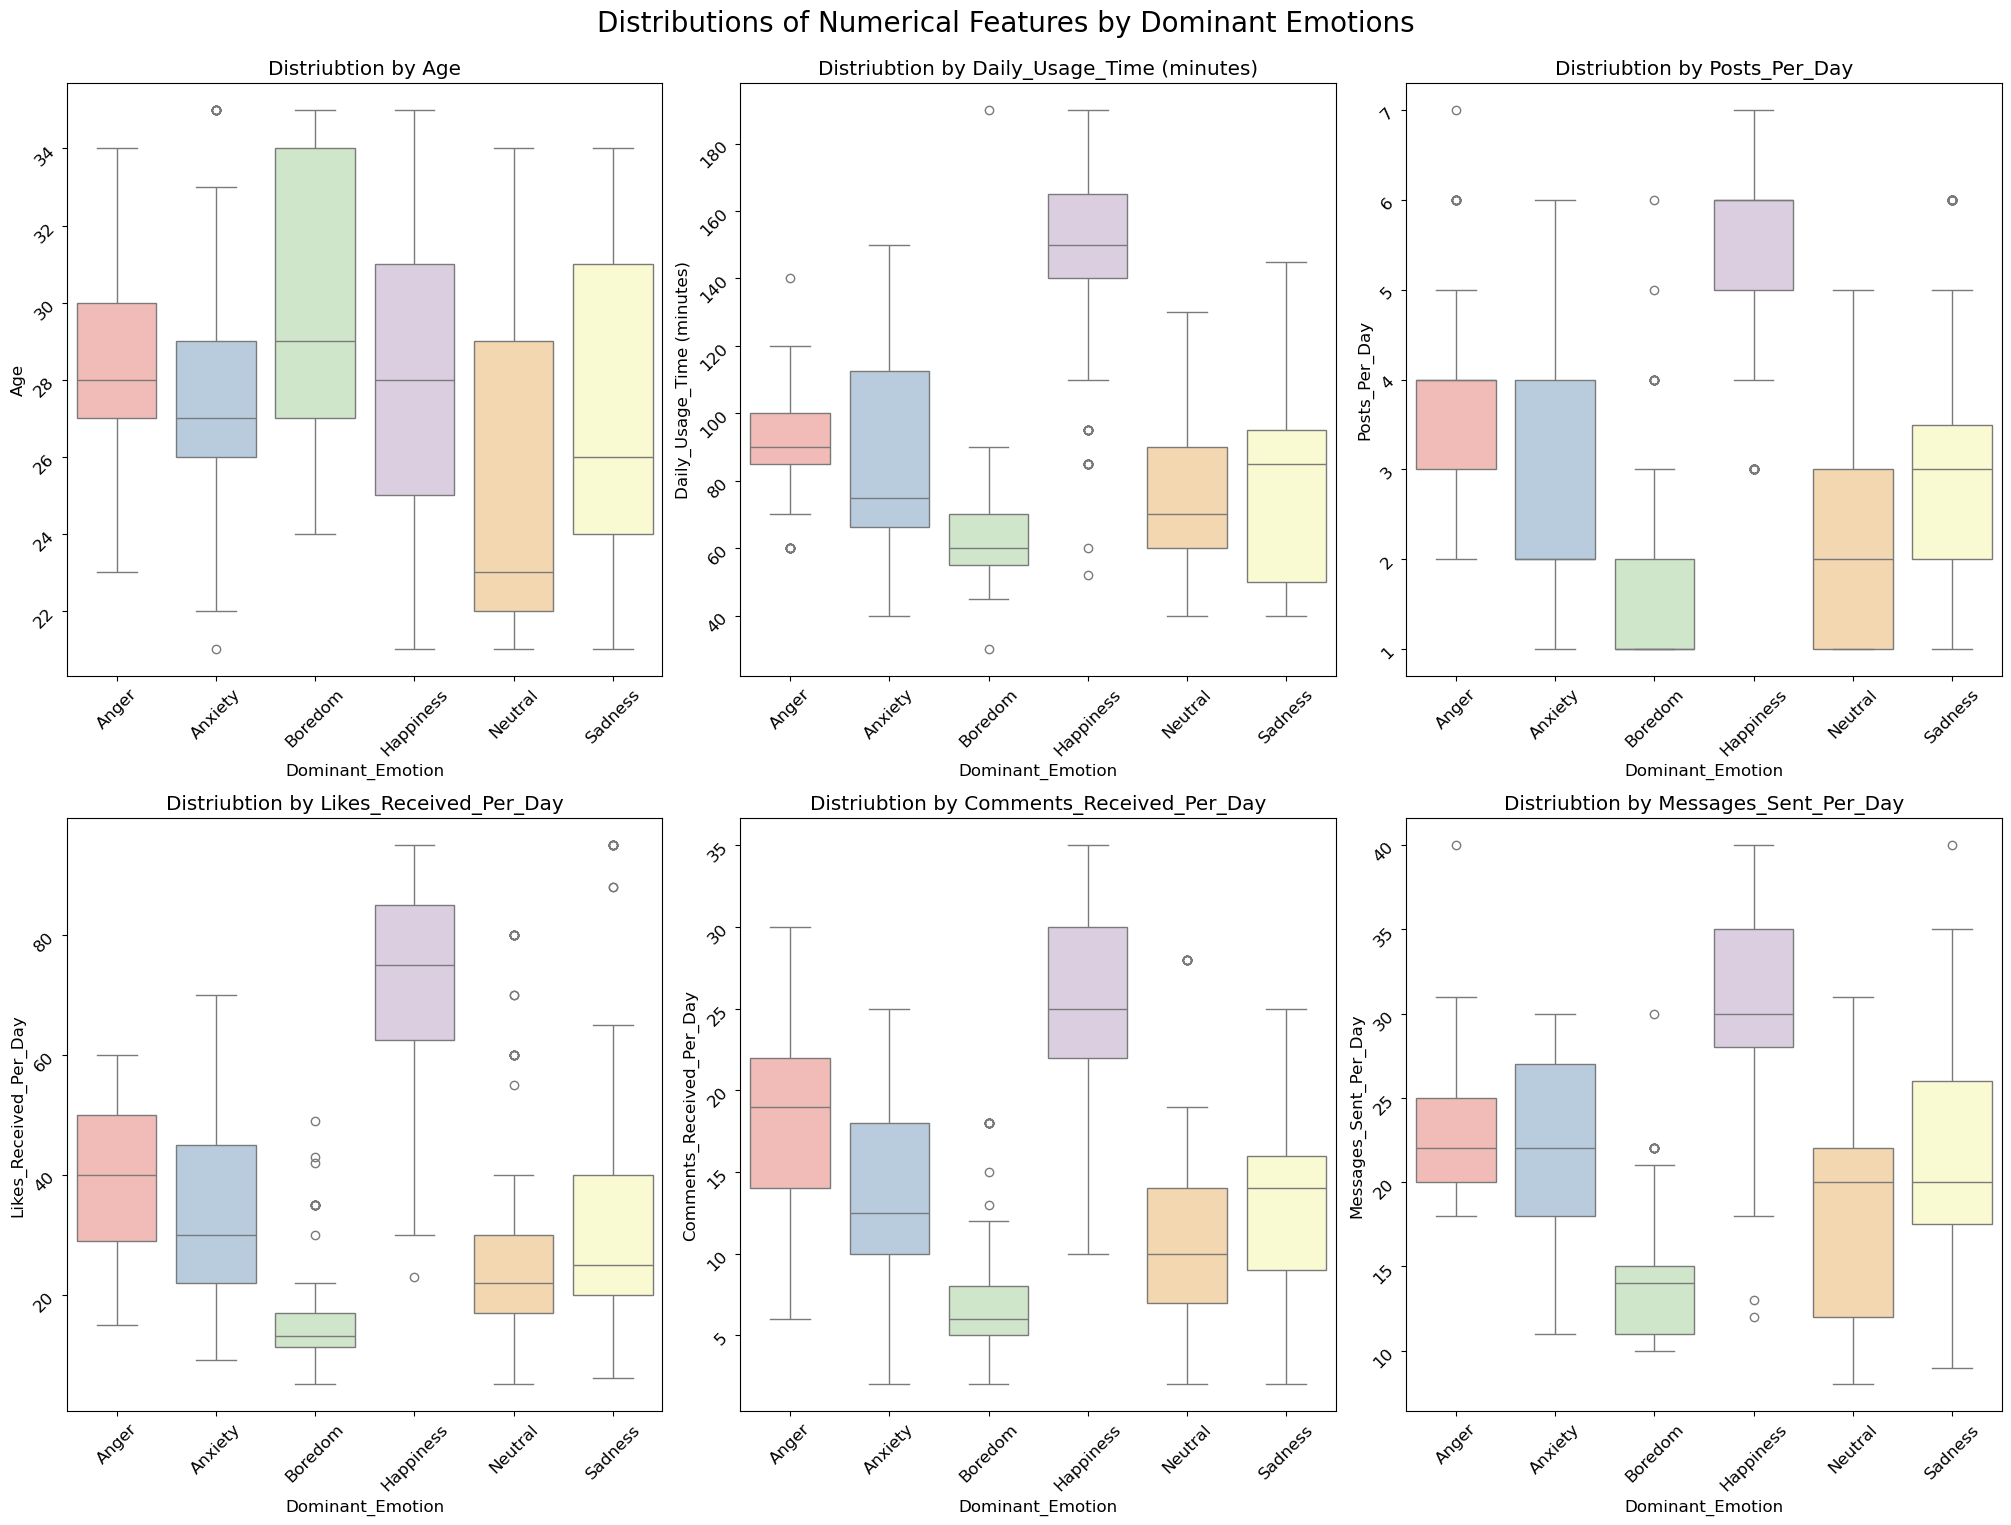

In [59]:
# Set up subplots
fig,_axes = plt.subplots(nrows=2, ncols=3, figsize=(20, 15), layout='constrained')
axes=_axes.flatten()

# Plot the numercial distrubtions with boxplots
i=0
for col in num_features:
    ax = sns.boxplot(data =social, y =col, ax=axes[i],  x = target , hue=target)
    ax.tick_params(labelrotation=45, labelsize=12)
    ax.set_title(f'Distriubtion by {col}')
    i=i+1

plt.suptitle('Distributions of Numerical Features by Dominant Emotions', fontsize=20, verticalalignment='center')
plt.show()

The plots show the following:
- Those in the late 20's are prone to feeling anger and anxiety.
- Those over the 30's are more likely to feel boredom.
- Those who spent over 2 hours a day on social media are more likely to feel happy.
- `Daily_Usage_Time (minutes)`, `Posts_Per_Day`, `Likes_Received_Per_Day`, `Comments_Received_Per_Day`, `Messages_Sent_Per_Day` have very similar distrubutions.

Check correlations between numerical features.

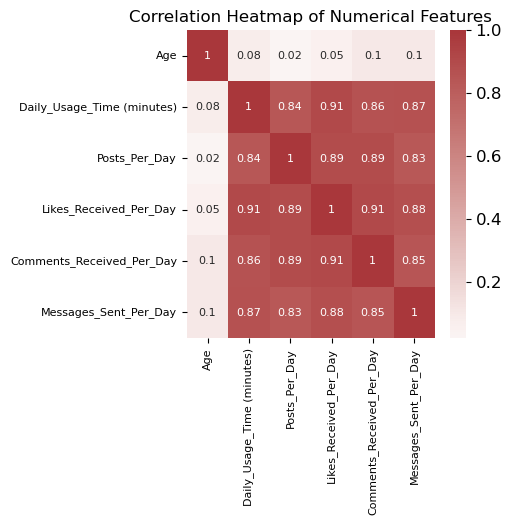

In [60]:
# Correlation heatmap of numerical features
fig, ax = plt.subplots(figsize=(4,4))      
ax = sns.heatmap(round(social[num_features].corr(), 2), annot=True, center=0,cmap="vlag", annot_kws={'size': 8})
ax.set_xticklabels(ax.get_xticklabels(), fontsize=8)
ax.set_yticklabels(ax.get_yticklabels(), fontsize=8)
plt.title('Correlation Heatmap of Numerical Features', fontsize=12)
plt.show()

The heatmap makes sense because the more users posts, likes posts, comments on posts, or sends messages, the more time they spend on social media.

`Daily_Usage_Time` has low correlation with `Age`. 

Plot the average `Daily_Usage_Time` against `Gender` and `Platform`.

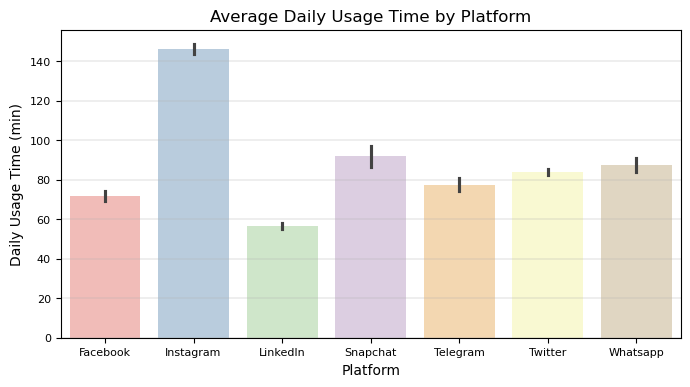

In [61]:
# Plot average daily usage time by platform
plt.figure(figsize=(8, 4))
ax = sns.barplot(x='Platform', y='Daily_Usage_Time (minutes)', data=social, estimator=np.mean, hue= 'Platform')
ax.grid(True, axis='y', linewidth=.3)
ax.set_xlabel("Platform", fontsize=10)
ax.set_ylabel("Daily Usage Time (min)", fontsize=10)
ax.tick_params(labelsize=8)
plt.title('Average Daily Usage Time by Platform', fontsize=12)
plt.show()

The plot shows that Instagram users spent the most amount of time, whereas LinkedIn users spend the least amount of time. 